<a href="https://colab.research.google.com/github/Abdisa-cyber/Data-Preprocessing-for-ML-using-Titanic-Dataset/blob/main/colab_Decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded=files.upload()

Saving employee_salary_dataset (1).csv to employee_salary_dataset (1).csv


In [5]:
from google.colab import files
import pandas as pd

# Upload the file
uploaded = files.upload()  # Click "Choose Files" and select your CSV

# Get the file name
filename = list(uploaded.keys())[0]

# Load the CSV
df = pd.read_csv(filename)

# Convert Monthly_Salary to classification (Low, Medium, High)
df['Salary_Class'] = pd.qcut(df['Monthly_Salary'], q=3, labels=['Low','Medium','High'])

# Check first 5 rows to see new column
print(df.head())

# Check dataset shape
print("Rows, Columns:", df.shape)

# Check distribution of Salary_Class
print("\nSalary class distribution:")
print(df['Salary_Class'].value_counts())


Saving employee_salary_dataset (1).csv to employee_salary_dataset (1) (2).csv
   EmployeeID        Name  Department  Experience_Years Education_Level  Age  \
0           1  Employee_1   Marketing                15          Master   53   
1           2  Employee_2  Operations                 7        Bachelor   25   
2           3  Employee_3          IT                12     High School   51   
3           4  Employee_4  Operations                 8             PhD   44   
4           5  Employee_5  Operations                15          Master   36   

   Gender       City  Monthly_Salary Salary_Class  
0  Female      Delhi          111416         High  
1  Female  Bangalore           95271       Medium  
2  Female  Hyderabad           69064       Medium  
3    Male      Delhi           95091       Medium  
4  Female      Delhi          132450         High  
Rows, Columns: (50, 10)

Salary class distribution:
Salary_Class
Low       17
High      17
Medium    16
Name: count, dtype: int64

In [6]:
# Features (all except salary columns)
X = df.drop(columns=['Monthly_Salary','Salary_Class'])

# Target (the new categorical salary)
y = df['Salary_Class']

# Check features and target
print("Features:", X.columns.tolist())
print("Target:", y.name)


Features: ['EmployeeID', 'Name', 'Department', 'Experience_Years', 'Education_Level', 'Age', 'Gender', 'City']
Target: Salary_Class


In [7]:
# Numeric columns
numeric_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()

# Categorical columns
categorical_cols = X.select_dtypes(include=['object','category','bool']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: ['EmployeeID', 'Experience_Years', 'Age']
Categorical columns: ['Name', 'Department', 'Education_Level', 'Gender', 'City']


In [8]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Numeric preprocessing: median imputation + scaling
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing: most frequent imputation + one-hot encoding
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine numeric and categorical transformers
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))


X_train: (40, 8) X_test: (10, 8)
y_train distribution:
 Salary_Class
Low       0.350
Medium    0.325
High      0.325
Name: proportion, dtype: float64


=== Entropy Decision Tree Results ===
Accuracy: 0.5

Classification report:
               precision    recall  f1-score   support

        High       0.60      0.75      0.67         4
         Low       0.40      0.67      0.50         3
      Medium       0.00      0.00      0.00         3

    accuracy                           0.50        10
   macro avg       0.33      0.47      0.39        10
weighted avg       0.36      0.50      0.42        10

Confusion matrix:
 [[3 1 0]
 [1 2 0]
 [1 2 0]]


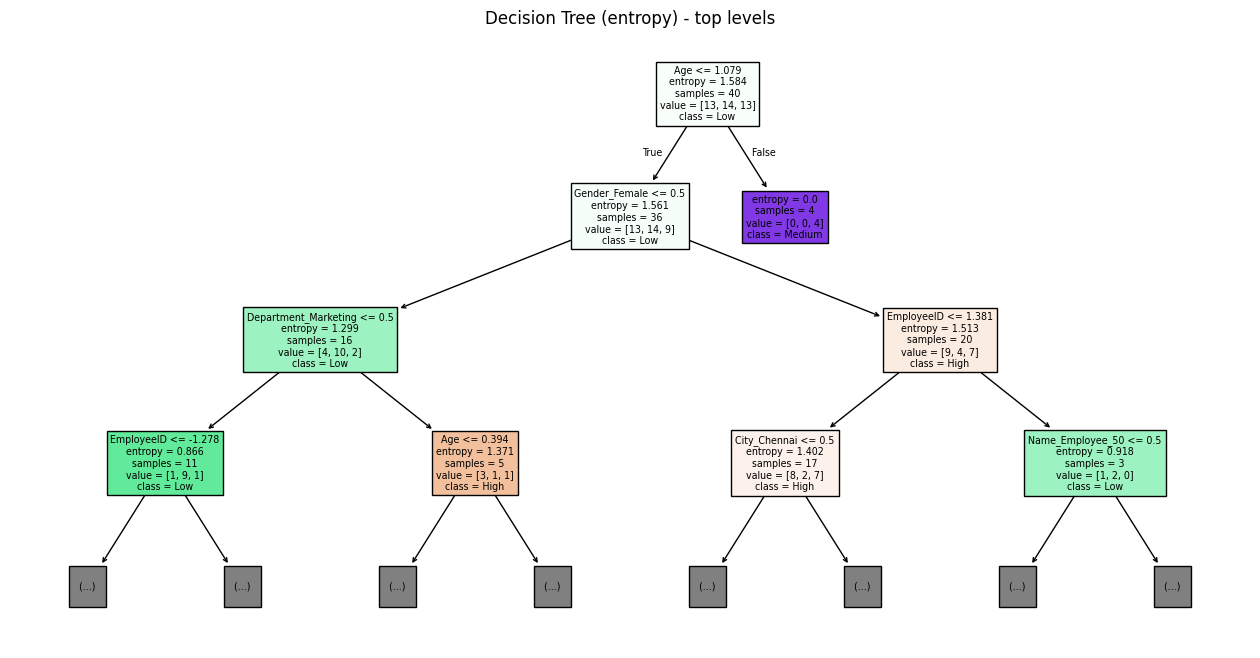

In [14]:
# === 5. Decision Tree (criterion = 'entropy') ===
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

dt_entropy = Pipeline(steps=[
    ('preproc', preprocessor),
    ('clf', DecisionTreeClassifier(criterion='entropy', random_state=42))
])

dt_entropy.fit(X_train, y_train)
y_pred_e = dt_entropy.predict(X_test)

print("=== Entropy Decision Tree Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_e))
print("\nClassification report:\n", classification_report(y_test, y_pred_e, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_e))

# Plot top levels of tree (max_depth=3 for readability)
try:
    # feature names after preprocessing
    feat_names = []
    feat_names.extend(numeric_cols)
    if categorical_cols:
        ohe = dt_entropy.named_steps['preproc'].named_transformers_['cat'].named_steps['onehot']
        feat_names.extend(list(ohe.get_feature_names_out(categorical_cols)))
    plt.figure(figsize=(16,8))
    plot_tree(dt_entropy.named_steps['clf'], feature_names=feat_names,
              class_names=[str(c) for c in dt_entropy.named_steps['clf'].classes_],
              filled=True, max_depth=3)
    plt.title("Decision Tree (entropy) - top levels")
    plt.show()
except Exception as e:
    print("Tree plot error:", e)


=== Gini Decision Tree Results ===
Accuracy: 0.5

Classification report:
               precision    recall  f1-score   support

        High       0.67      0.50      0.57         4
         Low       0.40      0.67      0.50         3
      Medium       0.50      0.33      0.40         3

    accuracy                           0.50        10
   macro avg       0.52      0.50      0.49        10
weighted avg       0.54      0.50      0.50        10

Confusion matrix:
 [[2 1 1]
 [1 2 0]
 [0 2 1]]


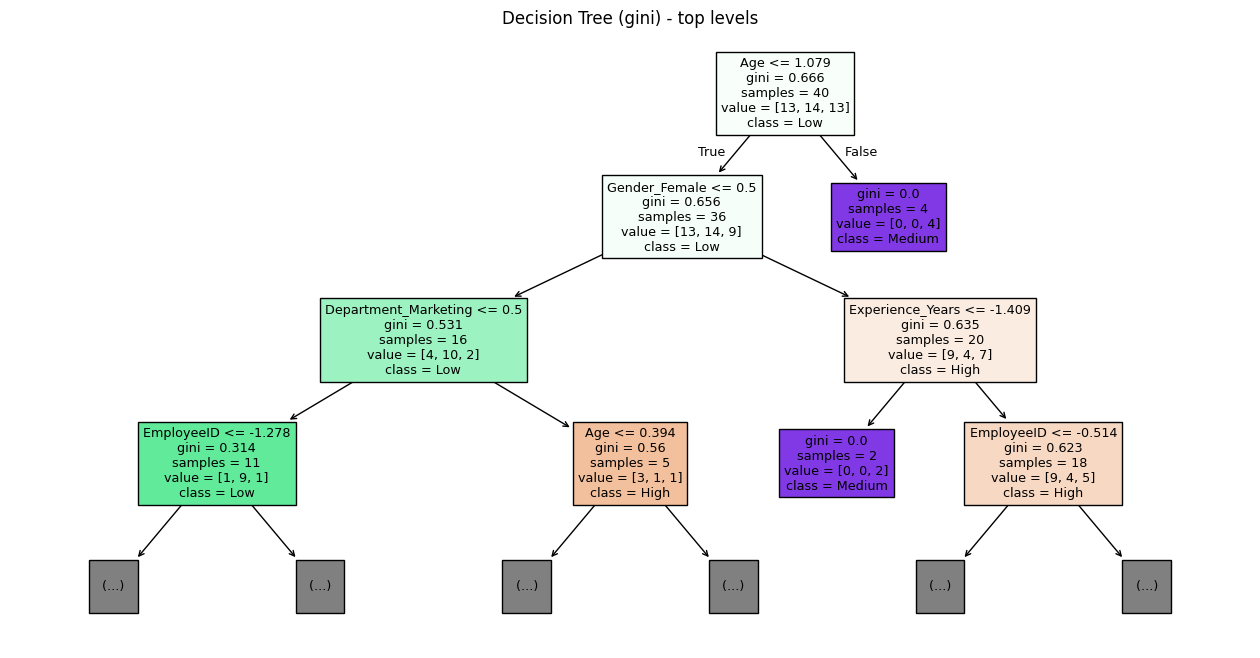

In [15]:
# === 6. Decision Tree (criterion = 'gini') ===
dt_gini = Pipeline(steps=[
    ('preproc', preprocessor),
    ('clf', DecisionTreeClassifier(criterion='gini', random_state=42))
])

dt_gini.fit(X_train, y_train)
y_pred_g = dt_gini.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

print("=== Gini Decision Tree Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_g))
print("\nClassification report:\n", classification_report(y_test, y_pred_g, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_g))

# Plot top levels
try:
    feat_names = []
    feat_names.extend(numeric_cols)
    if categorical_cols:
        ohe = dt_gini.named_steps['preproc'].named_transformers_['cat'].named_steps['onehot']
        feat_names.extend(list(ohe.get_feature_names_out(categorical_cols)))
    plt.figure(figsize=(16,8))
    plot_tree(dt_gini.named_steps['clf'], feature_names=feat_names,
              class_names=[str(c) for c in dt_gini.named_steps['clf'].classes_],
              filled=True, max_depth=3)
    plt.title("Decision Tree (gini) - top levels")
    plt.show()
except Exception as e:
    print("Tree plot error:", e)


=== Log-loss Decision Tree Results ===
Accuracy: 0.5

Classification report:
               precision    recall  f1-score   support

        High       0.60      0.75      0.67         4
         Low       0.40      0.67      0.50         3
      Medium       0.00      0.00      0.00         3

    accuracy                           0.50        10
   macro avg       0.33      0.47      0.39        10
weighted avg       0.36      0.50      0.42        10

Confusion matrix:
 [[3 1 0]
 [1 2 0]
 [1 2 0]]


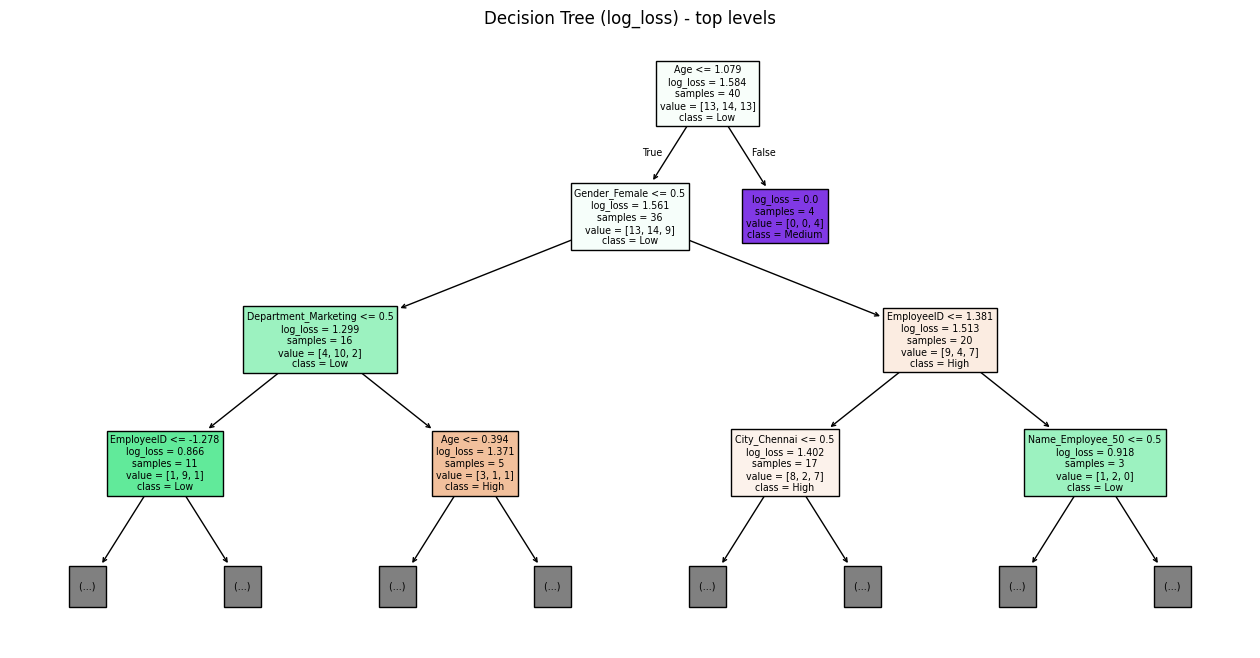

In [16]:
# === 7. Decision Tree (criterion = 'log_loss') ===
dt_log = Pipeline(steps=[
    ('preproc', preprocessor),
    ('clf', DecisionTreeClassifier(criterion='log_loss', random_state=42))
])

dt_log.fit(X_train, y_train)
y_pred_l = dt_log.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

print("=== Log-loss Decision Tree Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_l))
print("\nClassification report:\n", classification_report(y_test, y_pred_l, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_l))

# Plot top levels
try:
    feat_names = []
    feat_names.extend(numeric_cols)
    if categorical_cols:
        ohe = dt_log.named_steps['preproc'].named_transformers_['cat'].named_steps['onehot']
        feat_names.extend(list(ohe.get_feature_names_out(categorical_cols)))
    plt.figure(figsize=(16,8))
    plot_tree(dt_log.named_steps['clf'], feature_names=feat_names,
              class_names=[str(c) for c in dt_log.named_steps['clf'].classes_],
              filled=True, max_depth=3)
    plt.title("Decision Tree (log_loss) - top levels")
    plt.show()
except Exception as e:
    print("Tree plot error:", e)


In [17]:
# === 8. Summary of the three models ===
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    'entropy': dt_entropy,
    'gini': dt_gini,
    'log_loss': dt_log
}

summary = []
for name, pipe in models.items():
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    summary.append({'criterion': name, 'accuracy': acc, 'precision_macro': prec, 'recall_macro': rec, 'f1_macro': f1})

import pandas as pd
print(pd.DataFrame(summary))

# If binary classification, show ROC AUC for each model
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

if len(y_test.unique()) == 2:
    plt.figure(figsize=(8,6))
    for name, pipe in models.items():
        try:
            y_prob = pipe.predict_proba(X_test)
            # If predict_proba gives ncols == 2, take column for positive class
            if y_prob.shape[1] == 2:
                y_score = y_prob[:,1]
            else:
                # fallback: use probability of the first class
                y_score = y_prob[:,0]
            auc = roc_auc_score(pd.Categorical(y_test).codes, y_score)
            fpr, tpr, _ = roc_curve(pd.Categorical(y_test).codes, y_score)
            plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
        except Exception as e:
            print(f"Could not compute ROC for {name}: {e}")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("ROC curves skipped (not a binary target).")


  criterion  accuracy  precision_macro  recall_macro  f1_macro
0   entropy       0.5         0.333333      0.472222  0.388889
1      gini       0.5         0.522222      0.500000  0.490476
2  log_loss       0.5         0.333333      0.472222  0.388889
ROC curves skipped (not a binary target).


In [18]:
# === 9. Interpretation sketches ===
print("Interpretation sketches:")
print("- Entropy (information gain): chooses splits that reduce uncertainty (information). Tends to be slightly more sensitive to class purity.")
print("- Gini impurity: measures probability of misclassification in a node. Often very similar to entropy but computationally cheaper; tends to prefer larger, purer child nodes.")
print("- Log-loss: optimizes the tree to minimize log-loss (better calibrated probabilities). Useful when probabilistic predictions matter (ranking, expected-cost decisions).")
print("\nUse the metrics above (accuracy, precision, recall, f1, and AUC if available) to decide which criterion performs best for your dataset.")
print("If classes are imbalanced, prefer class_weight='balanced' or resampling; consider cross-validation and hyperparameter tuning (max_depth, min_samples_leaf).")


Interpretation sketches:
- Entropy (information gain): chooses splits that reduce uncertainty (information). Tends to be slightly more sensitive to class purity.
- Gini impurity: measures probability of misclassification in a node. Often very similar to entropy but computationally cheaper; tends to prefer larger, purer child nodes.
- Log-loss: optimizes the tree to minimize log-loss (better calibrated probabilities). Useful when probabilistic predictions matter (ranking, expected-cost decisions).

Use the metrics above (accuracy, precision, recall, f1, and AUC if available) to decide which criterion performs best for your dataset.
If classes are imbalanced, prefer class_weight='balanced' or resampling; consider cross-validation and hyperparameter tuning (max_depth, min_samples_leaf).
